In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
url = "http://books.toscrape.com"
response = requests.get(url)

print(response.status_code)

200


In [6]:
soup = BeautifulSoup(response.content, "html.parser")

books = soup.find_all("article", class_="product_pod")

print(len(books))

20


In [8]:
first_book = books[0]

title = first_book.find("h3").find("a")["title"]
price = first_book.find("p", class_="price_color").text
rating_class = first_book.find("p", class_="star-rating")["class"]

print(title)
print(price)
print(rating_class)

A Light in the Attic
£51.77
['star-rating', 'Three']


In [10]:
def parse_rating(class_list):
    rating_map = {
        "One": 1,
        "Two": 2,
        "Three": 3,
        "Four": 4,
        "Five": 5
    }
    
    for r in rating_map:
        if r in class_list:
            return rating_map[r]

In [12]:
rating_class = first_book.find("p", class_="star-rating")["class"]

In [14]:
parse_rating(rating_class)

3

In [16]:
books_data = []

for book in books:
    
    title = book.find("h3").find("a")["title"]
    
    price = book.find("p", class_="price_color").text
    price = float(price.replace("£",""))
    
    rating_class = book.find("p", class_="star-rating")["class"]
    rating = parse_rating(rating_class)
    
    books_data.append({
        "Title": title,
        "Price": price,
        "Rating": rating
    })

books_data[:5]

[{'Title': 'A Light in the Attic', 'Price': 51.77, 'Rating': 3},
 {'Title': 'Tipping the Velvet', 'Price': 53.74, 'Rating': 1},
 {'Title': 'Soumission', 'Price': 50.1, 'Rating': 1},
 {'Title': 'Sharp Objects', 'Price': 47.82, 'Rating': 4},
 {'Title': 'Sapiens: A Brief History of Humankind',
  'Price': 54.23,
  'Rating': 5}]

In [18]:
df = pd.DataFrame(books_data)
df.head()

,Title,Price,Rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


In [20]:
df["Rating"].value_counts()

Rating
1    6
4    4
5    4
3    3
2    3
Name: count, dtype: int64

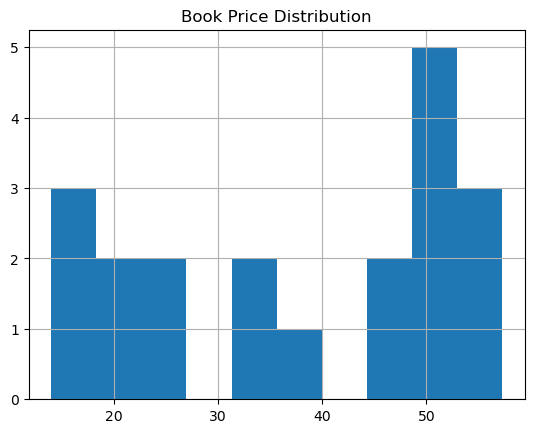

In [22]:
df["Price"].hist()
plt.title("Book Price Distribution")
plt.show()

In [24]:
def parse_book(book):
    title = book.find("h3").find("a")["title"]

    price_text = book.find("p", class_="price_color").text
    price = float(price_text.replace("£", ""))

    rating_classes = book.find("p", class_="star-rating")["class"]
    rating = parse_rating(rating_classes)

    return {
        "Title": title,
        "Price": price,
        "Rating": rating
    }

In [29]:
def parse_book(book):

    title = book.find("h3").find("a")["title"]

    price_text = book.find("p", class_="price_color").text
    price = float(price_text.replace("£",""))

    rating_classes = book.find("p", class_="star-rating")["class"]
    rating = parse_rating(rating_classes)

    return {
        "Title": title,
        "Price": price,
        "Rating": rating
    }

In [32]:
all_books_df = pd.DataFrame(all_books)

all_books_df.head()

,Title,Price,Rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


In [34]:
rating_classes = book.find("p", class_="star-rating")["class"]

In [36]:
def parse_book(book):
    title = book.find("h3").find("a")["title"]

    price_text = book.find("p", class_="price_color").text
    price = float(price_text.replace("£", ""))

    rating_classes = book.find("p", class_="star-rating")["class"]
    rating = parse_rating(rating_classes)

    return {
        "Title": title,
        "Price": price,
        "Rating": rating
    }

In [38]:
all_books_df.to_csv("books_scraped.csv", index=False)
all_books_df.to_excel("books_scraped.xlsx", index=False)

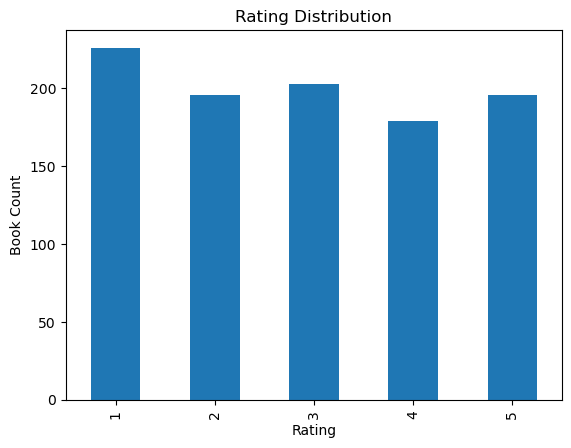

In [40]:
all_books_df["Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Book Count")
plt.show()

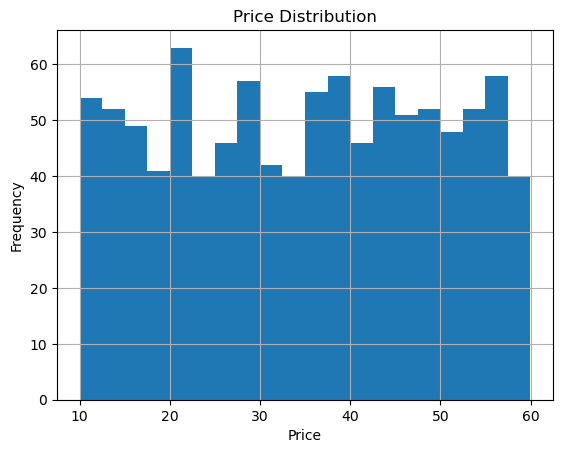

In [42]:
all_books_df["Price"].hist(bins=20)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [44]:
all_books_df.shape

(1000, 3)